In [ ]:
!pip install cdsapi xarray netCDF4 matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 71.4 MB/s eta 0:00:00


In [ ]:
from google.colab import userdata

url = userdata.get("CDSAPI_URL")
key = userdata.get("CDSAPI_KEY")

with open("/root/.cdsapirc", "w") as f:
    f.write(f"url: {url}\n")
    f.write(f"key: {key}\n")

print("CDS API configured")

CDS API configured


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_dir = "/content/drive/MyDrive/FourCastProject"

os.makedirs(project_dir, exist_ok=True)
os.makedirs(f"{project_dir}/data", exist_ok=True)
os.makedirs(f"{project_dir}/outputs", exist_ok=True)

print("Folders created successfully")

Folders created successfully


In [ ]:
!ls "/content/drive/MyDrive/FourCastProject"

data  outputs


In [ ]:
import cdsapi

client = cdsapi.Client()

In [ ]:
client.retrieve(
    "reanalysis-era5-single-levels",
    {
        "product_type": "reanalysis",
        "variable": [
            "10m_u_component_of_wind",
            "10m_v_component_of_wind",
            "2m_temperature",
            "mean_sea_level_pressure",
        ],
        "year": "2023",
        "month": "01",
        "day": [
            "01","02","03","04","05","06","07"
        ],
        "time": [
            "00:00",
            "06:00",
            "12:00",
            "18:00",
        ],
        "area": [
            -60,   # North
            50,    # West
            -90,   # South
            100,   # East
        ],
        "format": "netcdf",
    },
    "/content/drive/MyDrive/FourCastProject/data/era5_test.nc",
)

2026-05-30 18:33:04,858 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
INFO:ecmwf.datastores.legacy_client:[2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-

6bd0b9a55d0136b0ca0affe0a417ce74.nc:   0%|          | 0.00/3.83M [00:00<?, ?B/s]

'/content/drive/MyDrive/FourCastProject/data/era5_test.nc'

In [ ]:
import xarray as xr

ds = xr.open_dataset(
    "/content/drive/MyDrive/FourCastProject/data/era5_test.nc"
)

print(ds)

<xarray.Dataset> Size: 11MB
Dimensions:     (valid_time: 28, latitude: 121, longitude: 201)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 224B 2023-01-01 ... 2023-01-07T18...
  * latitude    (latitude) float64 968B -60.0 -60.25 -60.5 ... -89.75 -90.0
  * longitude   (longitude) float64 2kB 50.0 50.25 50.5 ... 99.5 99.75 100.0
    number      int64 8B ...
    expver      (valid_time) <U4 448B ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 3MB ...
    v10         (valid_time, latitude, longitude) float32 3MB ...
    t2m         (valid_time, latitude, longitude) float32 3MB ...
    msl         (valid_time, latitude, longitude) float32 3MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-

In [ ]:
import matplotlib.pyplot as plt

ds["t2m"].isel(time=0).plot()
plt.show()

ValueError: Dimensions {'time'} do not exist. Expected one or more of ('valid_time', 'latitude', 'longitude')

In [ ]:
ds = ds.rename({"valid_time": "time"})

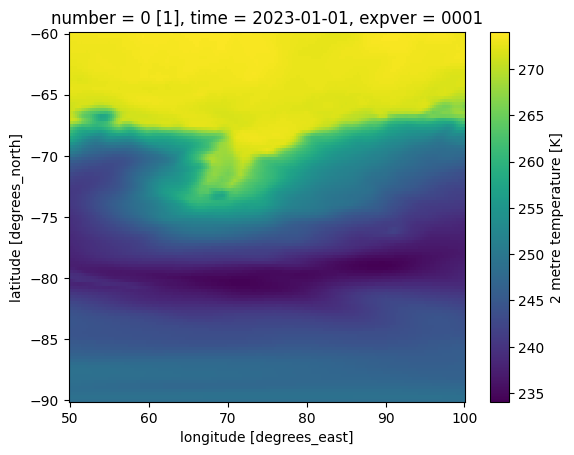

In [ ]:
ds["t2m"].isel(time=0).plot()
plt.show()

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
!find /content/drive/MyDrive -name "*.nc"

/content/drive/MyDrive/FourCastProject/data/era5_test.nc


In [13]:
import xarray as xr

ds = xr.open_dataset(
    "/content/drive/MyDrive/FourCastProject/data/era5_test.nc"
)

print(ds)

<xarray.Dataset> Size: 11MB
Dimensions:     (valid_time: 28, latitude: 121, longitude: 201)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 224B 2023-01-01 ... 2023-01-07T18...
  * latitude    (latitude) float64 968B -60.0 -60.25 -60.5 ... -89.75 -90.0
  * longitude   (longitude) float64 2kB 50.0 50.25 50.5 ... 99.5 99.75 100.0
    number      int64 8B ...
    expver      (valid_time) <U4 448B ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 3MB ...
    v10         (valid_time, latitude, longitude) float32 3MB ...
    t2m         (valid_time, latitude, longitude) float32 3MB ...
    msl         (valid_time, latitude, longitude) float32 3MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-

In [14]:
print(ds.dims)
print(list(ds.data_vars))
print(ds["t2m"].shape)

FrozenMappingWarningOnValuesAccess({'valid_time': 28, 'latitude': 121, 'longitude': 201})
['u10', 'v10', 't2m', 'msl']
(28, 121, 201)


In [15]:
if "valid_time" in ds.dims:
    ds = ds.rename({"valid_time": "time"})

In [16]:
print(ds.dims)

FrozenMappingWarningOnValuesAccess({'time': 28, 'latitude': 121, 'longitude': 201})


In [17]:
import numpy as np

data = np.stack(
    [
        ds["u10"].values,
        ds["v10"].values,
        ds["t2m"].values,
        ds["msl"].values,
    ],
    axis=1
)

print(data.shape)

(28, 4, 121, 201)


In [18]:
input_steps = 4

X = []
Y = []

for i in range(len(data) - input_steps):
    X.append(data[i:i+input_steps])
    Y.append(data[i+input_steps])

X = np.array(X)
Y = np.array(Y)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (24, 4, 4, 121, 201)
Y shape: (24, 4, 121, 201)


In [19]:
print(X.dtype)
print(Y.dtype)
print(X.nbytes / 1024**2, "MB")

float32
float32
35.62646484375 MB


In [20]:
means = data.mean(axis=(0, 2, 3))
stds  = data.std(axis=(0, 2, 3))

print("Means:", means)
print("Stds :", stds)

Means: [-5.1250868e-02 -2.0384780e-01  2.5297388e+02  9.8856586e+04]
Stds : [  5.195101    3.7333837  13.177288  776.61865  ]


In [22]:
data_norm = data.copy()

for c in range(4):
    data_norm[:, c] = (
        data_norm[:, c] - means[c]
    ) / stds[c]

In [23]:
for c in range(4):
    print(
        f"Channel {c}: "
        f"mean={data_norm[:, c].mean():.4f}, "
        f"std={data_norm[:, c].std():.4f}"
    )

Channel 0: mean=0.0000, std=1.0000
Channel 1: mean=0.0000, std=1.0000
Channel 2: mean=-0.0000, std=1.0000
Channel 3: mean=0.0000, std=1.0000


In [24]:
input_steps = 4

X = []
Y = []

for i in range(len(data_norm) - input_steps):
    X.append(data_norm[i:i+input_steps])
    Y.append(data_norm[i+input_steps])

X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.float32)

print(X.shape)
print(Y.shape)

(24, 4, 4, 121, 201)
(24, 4, 121, 201)


In [25]:
np.save(
    "/content/drive/MyDrive/FourCastProject/data/means.npy",
    means
)

np.save(
    "/content/drive/MyDrive/FourCastProject/data/stds.npy",
    stds
)

In [28]:
import sys

sys.path.append(
    "/content/NCPOR-BITS/FourCast+CorrDiff/FourCast"
)

In [34]:
%cd /content

!git clone https://github.com/AdityaLaddha47/NCPOR-BITS.git

/content
Cloning into 'NCPOR-BITS'...
remote: Enumerating objects: 159, done.
remote: Counting objects: 100% (159/159), done.
remote: Compressing objects: 100% (137/137), done.
remote: Total 159 (delta 29), reused 91 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (159/159), 4.00 MiB | 10.85 MiB/s, done.
Resolving deltas: 100% (29/29), done.


In [35]:
!find /content/NCPOR-BITS -maxdepth 3 -type d

/content/NCPOR-BITS
/content/NCPOR-BITS/FourCast+CorrDiff
/content/NCPOR-BITS/FourCast+CorrDiff/FourCast
/content/NCPOR-BITS/FourCast+CorrDiff/FourCast/CorrDiff
/content/NCPOR-BITS/FourCast+CorrDiff/FourCast/FourCast
/content/NCPOR-BITS/MOM6
/content/NCPOR-BITS/MOM6/Weddell
/content/NCPOR-BITS/MOM6/Weddell/results
/content/NCPOR-BITS/MOM6/Weddell/config
/content/NCPOR-BITS/.git
/content/NCPOR-BITS/.git/logs
/content/NCPOR-BITS/.git/logs/refs
/content/NCPOR-BITS/.git/hooks
/content/NCPOR-BITS/.git/branches
/content/NCPOR-BITS/.git/info
/content/NCPOR-BITS/.git/refs
/content/NCPOR-BITS/.git/refs/heads
/content/NCPOR-BITS/.git/refs/tags
/content/NCPOR-BITS/.git/refs/remotes
/content/NCPOR-BITS/.git/objects
/content/NCPOR-BITS/.git/objects/info
/content/NCPOR-BITS/.git/objects/pack
/content/NCPOR-BITS/transformer model
/content/NCPOR-BITS/Graphcast
/content/NCPOR-BITS/Graphcast/graphcast
/content/NCPOR-BITS/Graphcast/graphcast/docs
/content/NCPOR-BITS/Graphcast/graphcast/graphcast


In [36]:
%cd /content/NCPOR-BITS/FourCast+CorrDiff/FourCast

/content/NCPOR-BITS/FourCast+CorrDiff/FourCast


In [38]:
%cd FourCast

/content/NCPOR-BITS/FourCast+CorrDiff/FourCast/FourCast


In [54]:
from torch.utils.data import Dataset
import torch

class ERA5Dataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


In [55]:
dataset = ERA5Dataset(X, Y)

print(len(dataset))

sample_x, sample_y = dataset[0]

print(sample_x.shape)
print(sample_y.shape)

24
torch.Size([4, 4, 121, 201])
torch.Size([4, 121, 201])


In [56]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True
)

In [57]:
for x_batch, y_batch in loader:
    print(x_batch.shape)
    print(y_batch.shape)
    break

torch.Size([2, 4, 4, 121, 201])
torch.Size([2, 4, 121, 201])


In [62]:
import torch
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 4, kernel_size=3, padding=1)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape

        x = x.reshape(B, T*C, H, W)

        return self.net(x)

In [63]:
model = BaselineCNN()

In [64]:
output = model(x_batch)

print("Input :", x_batch.shape)
print("Output:", output.shape)
print("Target:", y_batch.shape)

Input : torch.Size([2, 4, 4, 121, 201])
Output: torch.Size([2, 4, 121, 201])
Target: torch.Size([2, 4, 121, 201])


In [65]:
import torch.nn as nn

criterion = nn.MSELoss()

loss = criterion(output, y_batch)

print(loss.item())

0.9570150971412659
